# Game analytics data-quality workflow

An end-to-end case study for `spark-data-quality`: profiling and validating a
synthetic player/session dataset before it is trusted as an input to an
analytics table, then a concise look at the library's optional Fugue
integration.

This notebook consumes the installed `spark_data_quality` package under
`src/`; it does not reimplement any check or profiling logic.

## 1. Scenario

A game analytics pipeline receives player/session records from a game
client SDK and stages them before loading a trusted analytics table used by
downstream dashboards and player-behavior models. Client SDKs, upstream
schema migrations, and network retries are common, realistic sources of bad
rows: missing identifiers, duplicate event submissions, out-of-range values,
and stale reference data.

Before this data is safe to load, we need explicit, machine-checkable
expectations about it — not just a visual glance at a few rows. That is the
role of `QualitySuite`.

**The dataset below is synthetic**, generated deterministically for this
notebook. It is not production data.

## 2. Load synthetic data

In [1]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder.master("local[2]")
    .appName("data-quality-workflow")
    .config("spark.driver.bindAddress", "127.0.0.1")
    .config("spark.ui.enabled", "false")
    .config("spark.sql.shuffle.partitions", "4")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")
spark.version

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/09/22 00:42:41 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


'4.1.3'

In [2]:
"""Deterministic synthetic game-session dataset.

Built with a fixed seed so the whole notebook is reproducible top to bottom
with no network access and no external dataset. Anomalies are injected at
known rates so the interpretation sections below describe results this
generator actually produces, not hypothetical ones.
"""

import random

SEED = 42
N_ROWS = 5_000

ALLOWED_COUNTRIES = ("US", "DE", "GB", "FR", "JP", "BR", "IN", "ZA", "AU", "CA")
INVALID_COUNTRIES = ("XX", "ZZ", "Q1", "us")
PLATFORMS = ("iOS", "Android", "Web")
COLUMN_ORDER = (
    "session_id",
    "player_id",
    "age",
    "country",
    "session_duration_seconds",
    "platform",
    "client_device_id",
)

rng = random.Random(SEED)

records = []
for i in range(1, N_ROWS + 1):
    records.append(
        {
            "session_id": f"s-{i:06d}",
            "player_id": i,
            "age": rng.randint(13, 65),
            "country": rng.choice(ALLOWED_COUNTRIES),
            "session_duration_seconds": rng.randint(5, 7_200),
            "platform": rng.choice(PLATFORMS),
            "client_device_id": f"dev-{i:08x}",
        }
    )

indices = list(range(N_ROWS))


def inject(count: int, mutate) -> list[int]:
    chosen = rng.sample(indices, k=count)
    for idx in chosen:
        mutate(records[idx])
    return chosen


missing_player_id = inject(85, lambda r: r.__setitem__("player_id", None))
invalid_age = inject(
    115, lambda r: r.__setitem__("age", rng.choice([-5, 0, 121, 150, 999]))
)
invalid_country = inject(
    40, lambda r: r.__setitem__("country", rng.choice(INVALID_COUNTRIES))
)
null_country = inject(15, lambda r: r.__setitem__("country", None))
invalid_duration = inject(
    70,
    lambda r: r.__setitem__(
        "session_duration_seconds", rng.choice([-30, -1, 14_401, 20_000, 100_000])
    ),
)
malformed_session_id = inject(
    25, lambda r: r.__setitem__("session_id", f"session_{rng.randint(1, 999_999)}")
)

# Duplicate session_id values: overwrite a sample of rows with another row's id.
duplicate_targets = rng.sample(indices, k=40)
for idx in duplicate_targets:
    donor = rng.choice(indices)
    records[idx]["session_id"] = records[donor]["session_id"]

schema = (
    "session_id string, player_id long, age long, country string, "
    "session_duration_seconds long, platform string, client_device_id string"
)
rows = [tuple(record[column] for column in COLUMN_ORDER) for record in records]
raw_sessions = spark.createDataFrame(rows, schema=schema)
raw_sessions.cache()
raw_sessions.count()

5000

In [3]:
raw_sessions.printSchema()

root
 |-- session_id: string (nullable = true)
 |-- player_id: long (nullable = true)
 |-- age: long (nullable = true)
 |-- country: string (nullable = true)
 |-- session_duration_seconds: long (nullable = true)
 |-- platform: string (nullable = true)
 |-- client_device_id: string (nullable = true)



In [4]:
raw_sessions.limit(10).toPandas()

,session_id,player_id,age,country,session_duration_seconds,platform,client_device_id
0,s-000001,1.0,53,DE,209,Web,dev-00000001
1,s-000002,2.0,30,FR,1833,iOS,dev-00000002
2,s-000003,3.0,60,DE,5548,Web,dev-00000003
3,s-000004,4.0,47,DE,4842,Android,dev-00000004
4,s-000005,NaN,15,US,772,iOS,dev-00000005
5,s-000006,6.0,27,AU,4936,iOS,dev-00000006
6,s-000007,7.0,48,FR,5870,Web,dev-00000007
7,s-000008,8.0,57,AU,3441,iOS,dev-00000008
8,s-000009,9.0,41,CA,2283,iOS,dev-00000009
9,s-000010,10.0,61,GB,5724,Android,dev-0000000a


`player_id` displays as a float above (with `NaN` for the missing rows) only
because this preview went through `.toPandas()`: pandas has no way to
represent a null inside a plain integer column, so it upcasts the whole
column to `float64` for display. The schema printed just above confirms the
underlying Spark column is `long` with real nulls — this display artifact is
the same pandas behavior documented in `spark_data_quality/fugue.py` for
data that arrives *from* pandas, shown here in the opposite direction purely
for context.

Separately, note the `client_device_id` column: a recent upstream migration
renamed the legacy `device_id` field. That mismatch is deliberately left in
the suite below (Section 4) to demonstrate the `ERROR` outcome later in
Section 7 with a realistic cause instead of a contrived one.

## 3. Profile before validation

`profile()` computes bounded, Spark-native statistics for selected columns:
null and distinct counts, numeric summary statistics, and (for string
columns) bounded top-value frequencies. It never collects the full dataset —
one shared scalar aggregate plus one bounded grouped query per string column.

In [5]:
from spark_data_quality import profile

profile_report = profile(
    raw_sessions,
    ["player_id", "age", "session_duration_seconds", "country", "platform", "session_id"],
    top_k=5,
)
profile_report.metadata

ProfileExecutionMetadata(aggregate_actions=1, aggregate_metric_count=31, top_value_actions=3, top_k=5, scalar_aggregation_duration_ms=2023.7420289995498, top_values_duration_ms=774.722724010644)

In [6]:
import pandas as pd

profile_rows = []
for column_profile in profile_report.columns:
    stats = column_profile.numeric or column_profile.string
    profile_rows.append(
        {
            "column": column_profile.column,
            "spark_type": column_profile.spark_type,
            "kind": column_profile.kind,
            "null_count": column_profile.null_count,
            "null_rate_pct": round(100 * column_profile.null_count / profile_report.row_count, 2),
            "distinct_count": column_profile.distinct_count,
        }
    )
profile_summary = pd.DataFrame(profile_rows)
profile_summary

,column,spark_type,kind,null_count,null_rate_pct,distinct_count
0,player_id,bigint,numeric,85,1.7,4915
1,age,bigint,numeric,0,0.0,58
2,session_duration_seconds,bigint,numeric,0,0.0,3595
3,country,string,string,15,0.3,14
4,platform,string,string,0,0.0,3
5,session_id,string,string,0,0.0,4960


In [7]:
age_profile = next(c for c in profile_report.columns if c.column == "age").numeric
print(f"age: min={age_profile.minimum}, max={age_profile.maximum}, mean={age_profile.mean:.1f}")
print(
    "The observed age range already exceeds a plausible player age band "
    "(13-120), which is exactly what the InRange check in Section 4 will catch "
    "explicitly and quantify."
)

age: min=-5, max=999, mean=43.8
The observed age range already exceeds a plausible player age band (13-120), which is exactly what the InRange check in Section 4 will catch explicitly and quantify.


The profile already reveals two things worth flagging before we even define
expectations: `player_id` and `country` have non-zero null rates, and `age`'s
observed range is implausible for a player. Profiling characterizes the data;
it does not decide pass/fail — that is `QualitySuite`'s job.

## 4. Define the QualitySuite

Each check below encodes one expectation this pipeline actually needs before
loading `raw_sessions` into the trusted analytics table:

| Check | Why it matters |
| --- | --- |
| `ColumnExists` / `NotNull` / `Unique` / `MatchesRegex` on `session_id` | `session_id` is the intended grain key; it must exist, be non-null, unique, and well-formed to safely dedupe or join downstream. |
| `ColumnExists` / `NotNull` / `HasType` on `player_id` | Every session must be attributable to a real player with the expected integral type. |
| `InRange` on `age` | Ages outside a plausible player band indicate corrupt input, not real users. |
| `NotNull` / `AllowedValues` on `country` | Downstream regional reporting assumes a closed, current set of country codes. |
| `InRange` on `session_duration_seconds` | Negative or implausibly long sessions indicate client bugs, not real play sessions. |
| `AllowedValues` on `platform` | Reporting dimensions assume a fixed, known platform set. |
| `RowCount` | A sanity floor against a truncated or empty upstream load. |
| `ColumnExists` / `NotNull` on `device_id` | Left over from before the `client_device_id` rename — included deliberately (see Section 7). |

This covers all eight built-in check types in one suite.

In [8]:
from pyspark.sql.types import LongType

from spark_data_quality import (
    AllowedValues,
    ColumnExists,
    HasType,
    InRange,
    MatchesRegex,
    NotNull,
    QualitySuite,
    RowCount,
    Unique,
)

suite = QualitySuite(
    name="game_sessions_ingest",
    checks=[
        ColumnExists("session_id"),
        NotNull("session_id"),
        Unique("session_id"),
        MatchesRegex("session_id", r"^s-\d{6}$"),
        ColumnExists("player_id"),
        NotNull("player_id"),
        HasType("player_id", LongType()),
        InRange("age", min_value=13, max_value=120),
        NotNull("country"),
        AllowedValues("country", frozenset(ALLOWED_COUNTRIES)),
        InRange("session_duration_seconds", min_value=0, max_value=14_400),
        AllowedValues("platform", frozenset(PLATFORMS)),
        RowCount(min_count=1_000),
        ColumnExists("device_id"),
        NotNull("device_id"),
    ],
)
len(suite.checks)

15

## 5. Aggregation planning

`QualitySuite.validate` plans and executes in one call. To make the planning
step visible, this section calls the same `AggregationPlanner` the suite uses
internally (see `tests/integration/test_planning.py` for the equivalent
regression test) purely to inspect its output — the actual validation run in
Section 6 goes through the public `suite.validate` API, not this planner
directly.

In [9]:
from spark_data_quality.execution.planning import AggregationPlanner

plan = AggregationPlanner(raw_sessions).plan(suite.checks)
value_level_checks = len(suite.checks) - plan.schema_check_count
print(f"total checks:               {len(suite.checks)}")
print(f"schema-only checks:         {plan.schema_check_count}  (no Spark action needed)")
print(f"value-level checks:         {value_level_checks}")
print(f"deduplicated agg metrics:   {len(plan.metrics)}  (one shared DataFrame.agg call)")

total checks:               15
schema-only checks:         4  (no Spark action needed)
value-level checks:         11
deduplicated agg metrics:   15  (one shared DataFrame.agg call)


Several checks share deterministic metric aliases: `Unique("session_id")` and
`MatchesRegex("session_id", ...)` both need the non-null count of
`session_id`, so the planner emits that expression once and both checks read
the same aggregate column. This is the concrete mechanism behind "one shared
aggregate action" — it is a claim about **one library-triggered
`DataFrame.agg` call**, not about the number of underlying Spark jobs,
stages, or physical scans Spark's own optimizer chooses to run for that one
aggregate (exact `countDistinct` in particular can introduce a shuffle and
therefore additional stages).

The cell below verifies the "one physical scan of the source" claim
mechanically — by counting Catalyst leaf nodes on the pre-AQE physical
plan — the same technique
`test_shared_aggregation_reads_the_source_exactly_once` uses, rather than by
asserting on operator names.

In [10]:
aggregated = raw_sessions.agg(*(metric.expression for metric in plan.metrics))
physical_plan = aggregated._jdf.queryExecution().sparkPlan()
print(f"physical scan (source leaf) nodes: {physical_plan.collectLeaves().length()}")

physical scan (source leaf) nodes: 1


## 6. Execute validation

In [11]:
report = suite.validate(raw_sessions)

results_summary = pd.DataFrame(
    [
        {
            "check_id": r.check_id,
            "check_type": r.check_type,
            "column": r.expected.get("column"),
            "status": r.status.value,
            "affected_rows": r.affected_rows,
            "evaluated_rows": r.evaluated_rows,
            "failure_fraction": r.failure_fraction,
        }
        for r in report.results
    ]
)
results_summary

,check_id,check_type,column,status,affected_rows,evaluated_rows,failure_fraction
0,column_exists:0,column_exists,session_id,PASS,NaN,NaN,NaN
1,not_null:1,not_null,session_id,PASS,0.0,5000.0,0.000000
2,unique:2,unique,session_id,FAIL,40.0,5000.0,0.008000
3,matches_regex:3,matches_regex,session_id,FAIL,24.0,5000.0,0.004800
4,column_exists:4,column_exists,player_id,PASS,NaN,NaN,NaN
5,not_null:5,not_null,player_id,FAIL,85.0,5000.0,0.017000
6,has_type:6,has_type,player_id,PASS,NaN,NaN,NaN
7,in_range:7,in_range,age,FAIL,115.0,5000.0,0.023000
8,not_null:8,not_null,country,FAIL,15.0,5000.0,0.003000
9,allowed_values:9,allowed_values,country,FAIL,40.0,4985.0,0.008024


In [12]:
print(f"suite status: {report.status.value}")
print(f"aggregate_actions (library-level Spark actions): {report.metadata.aggregate_actions}")
print(f"aggregate_metric_count: {report.metadata.aggregate_metric_count}")
print(f"schema_check_count: {report.metadata.schema_check_count}")

suite status: ERROR
aggregate_actions (library-level Spark actions): 1
aggregate_metric_count: 15
schema_check_count: 4


## 7. PASS / FAIL / ERROR

- **PASS** — a valid expectation was evaluated and the data satisfied it.
- **FAIL** — a valid expectation was evaluated and the data violated it.
- **ERROR** — the expectation could not be evaluated at all.

The suite above demonstrates all three without any artificial detour from the
normal workflow: the `device_id` checks are a genuine leftover from the
`client_device_id` rename described in Section 2.

In [13]:
from spark_data_quality import CheckStatus

status_counts = pd.Series([r.status.value for r in report.results]).value_counts()
print(status_counts.to_string())

column_exists_device = next(r for r in report.results if r.check_id == "column_exists:13")
not_null_device = next(r for r in report.results if r.check_id == "not_null:14")

print()
print(f"ColumnExists('device_id') -> {column_exists_device.status.value}")
print("  A missing column is a valid, directly answerable expectation for ColumnExists")
print("  itself, so it is FAIL rather than ERROR.")
print()
print(f"NotNull('device_id') -> {not_null_device.status.value}")
print(f"  diagnostic: {not_null_device.diagnostic.code} - {not_null_device.diagnostic.message}")
print("  NotNull cannot evaluate a column that is not present, so it is ERROR -")
print("  and every other check in the same suite still ran and completed normally.")
assert report.status is CheckStatus.ERROR

FAIL     8
PASS     6
ERROR    1

ColumnExists('device_id') -> FAIL
  A missing column is a valid, directly answerable expectation for ColumnExists
  itself, so it is FAIL rather than ERROR.

NotNull('device_id') -> ERROR
  diagnostic: MISSING_COLUMN - Required column 'device_id' does not exist
  NotNull cannot evaluate a column that is not present, so it is ERROR -
  and every other check in the same suite still ran and completed normally.


## 8. Failure diagnostics

`affected_rows` and `failure_fraction` are precisely defined per check (see
`docs/architecture.md`): for null-ignoring checks the denominator
(`evaluated_rows`) is the non-null count, not the total row count, so
`failure_fraction` answers "what fraction of the values this check could
actually evaluate were invalid" rather than being diluted by an unrelated
column's nulls.

In [14]:
failures = results_summary[results_summary["status"] == "FAIL"].sort_values(
    "failure_fraction", ascending=False
)
failures

,check_id,check_type,column,status,affected_rows,evaluated_rows,failure_fraction
7,in_range:7,in_range,age,FAIL,115.0,5000.0,0.023000
5,not_null:5,not_null,player_id,FAIL,85.0,5000.0,0.017000
10,in_range:10,in_range,session_duration_seconds,FAIL,70.0,5000.0,0.014000
9,allowed_values:9,allowed_values,country,FAIL,40.0,4985.0,0.008024
2,unique:2,unique,session_id,FAIL,40.0,5000.0,0.008000
3,matches_regex:3,matches_regex,session_id,FAIL,24.0,5000.0,0.004800
8,not_null:8,not_null,country,FAIL,15.0,5000.0,0.003000
13,column_exists:13,column_exists,device_id,FAIL,NaN,NaN,NaN


## 9. Visual quality report

In [15]:
"""Two bounded, high-value figures: a small aggregated result -> Plotly -> PNG.

Neither figure collects the source DataFrame; both are built from the already
-computed `report` and `profile_report` objects (small, bounded Python
structures), consistent with the architecture this library documents.
"""

from pathlib import Path

import plotly.graph_objects as go

ASSETS_DIR = Path("..") / "docs" / "assets" / "data-quality-workflow"
ASSETS_DIR.mkdir(parents=True, exist_ok=True)

STATUS_COLORS = {"PASS": "#0ca30c", "FAIL": "#d03b3b", "ERROR": "#52514e"}
STATUS_ORDER = {"ERROR": 0, "FAIL": 1, "PASS": 2}


def check_label(result) -> str:
    column = result.expected.get("column")
    check_type = result.check_type.replace("_", " ")
    return f"{check_type} ({column})" if column else check_type


ordered_results = sorted(
    report.results,
    key=lambda r: (STATUS_ORDER[r.status.value], -(r.failure_fraction or 0)),
)
labels_top_to_bottom = [check_label(r) for r in ordered_results]

fig = go.Figure()

# ERROR has no failure_fraction (the expectation could not be evaluated at
# all), so it is drawn as a marker at the axis origin rather than a
# zero-length bar, which would render with no visible color at all. Added
# first so the legend lists ERROR, FAIL, PASS in the same severity order as
# the bars themselves.
error_subset = [r for r in ordered_results if r.status.value == "ERROR"]
if error_subset:
    fig.add_trace(
        go.Scatter(
            name="ERROR",
            y=[check_label(r) for r in error_subset],
            x=[0.0] * len(error_subset),
            mode="markers+text",
            marker=dict(symbol="diamond", size=14, color=STATUS_COLORS["ERROR"]),
            text=["not evaluated"] * len(error_subset),
            textposition="middle right",
            cliponaxis=False,
        )
    )

for status in ("FAIL", "PASS"):
    subset = [r for r in ordered_results if r.status.value == status]
    if not subset:
        continue
    fig.add_trace(
        go.Bar(
            name=status,
            y=[check_label(r) for r in subset],
            x=[100 * (r.failure_fraction or 0.0) for r in subset],
            orientation="h",
            marker_color=STATUS_COLORS[status],
            text=[f"{100 * (r.failure_fraction or 0.0):.1f}%" for r in subset],
            textposition="outside",
            cliponaxis=False,
        )
    )

fig.update_yaxes(categoryorder="array", categoryarray=list(reversed(labels_top_to_bottom)))
fig.update_xaxes(title_text="Failure fraction of evaluated rows (%)", rangemode="tozero")
fig.update_layout(
    title="game_sessions_ingest — check outcomes",
    template="plotly_white",
    legend_title_text="Status",
    height=560,
    width=880,
    margin=dict(l=260, r=60, t=60, b=50),
    font=dict(size=13),
)

quality_results_path = ASSETS_DIR / "quality-results.png"
fig.write_image(str(quality_results_path), scale=2)

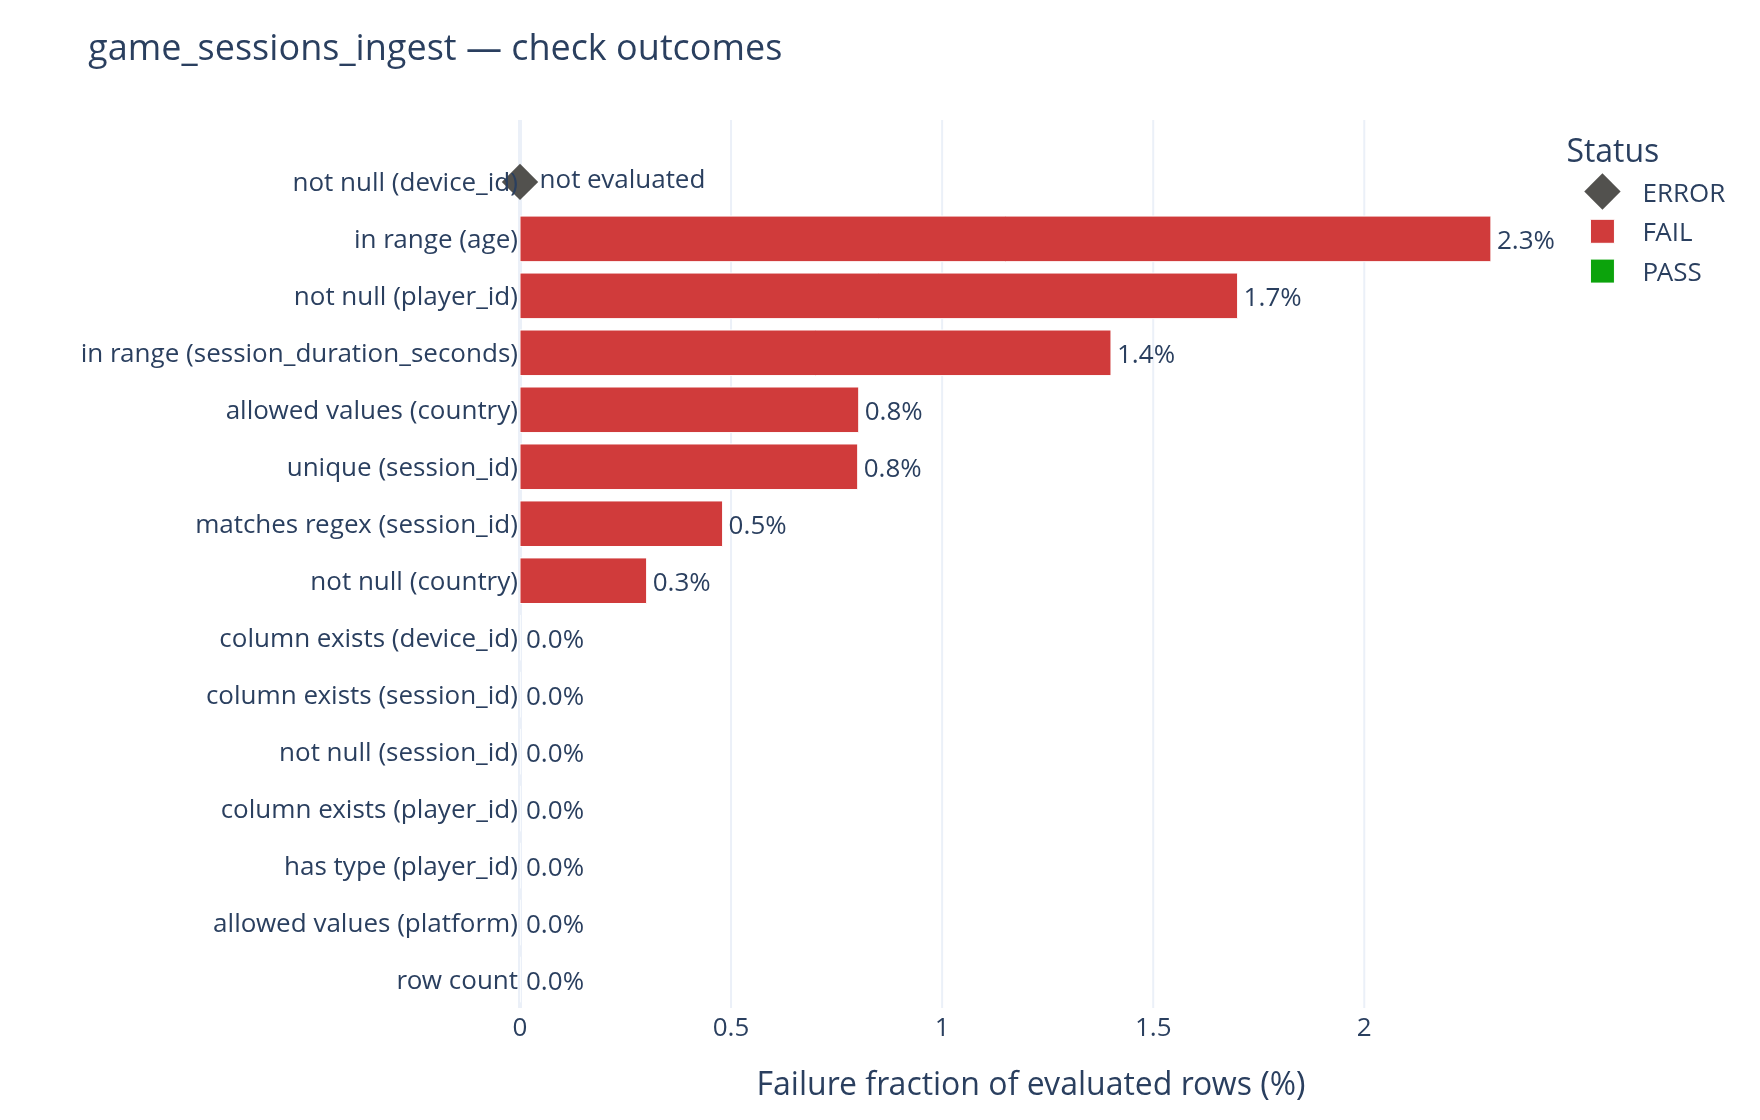

In [16]:
from IPython.display import Image, display

display(Image(filename=str(quality_results_path)))

Color marks status (green/red/gray) and every bar also carries a direct text
label, so the outcome and its magnitude are both readable without relying on
color alone.

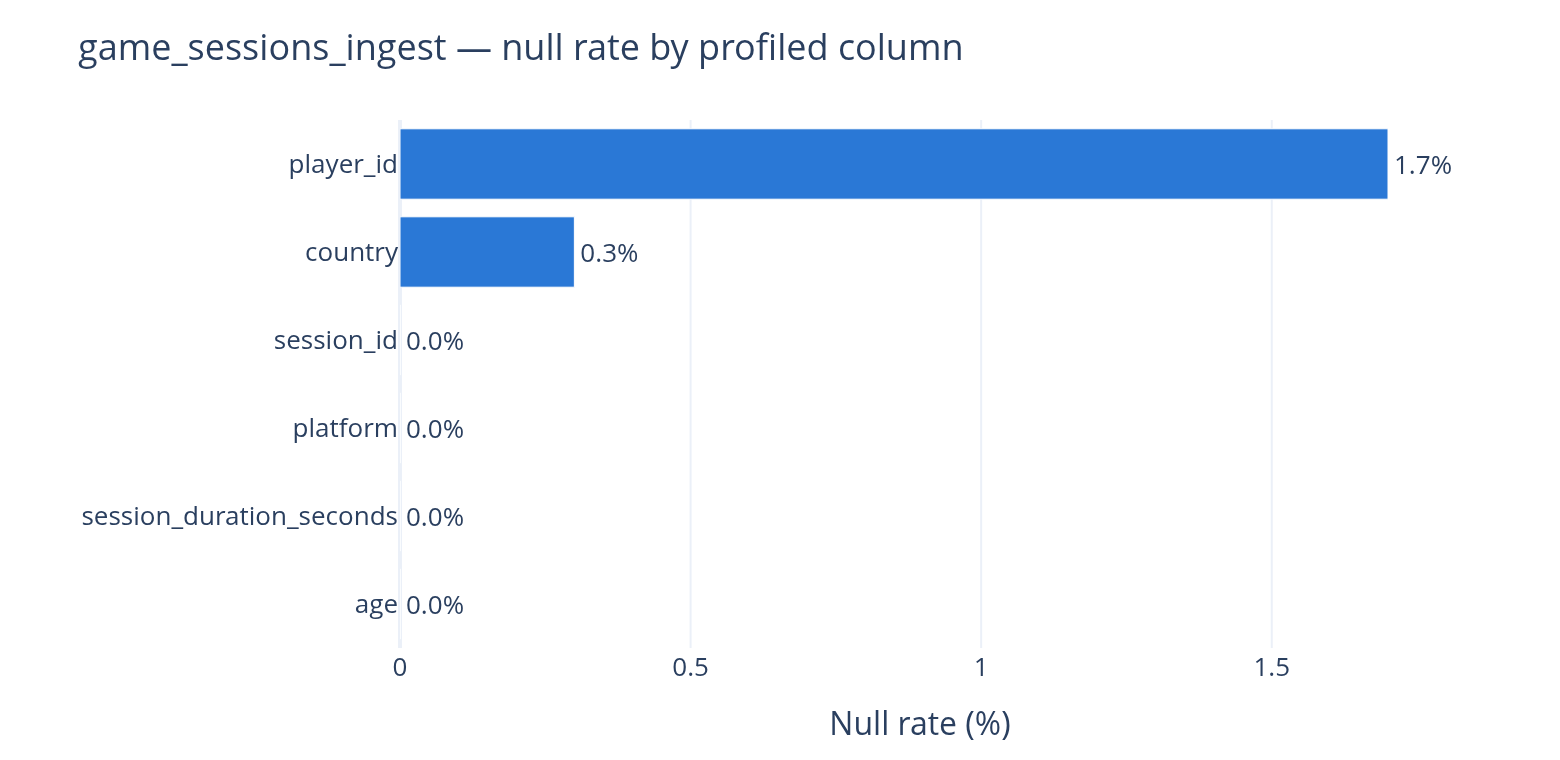

In [17]:
"""Bounded null-rate profile: one small aggregated result per selected column."""

null_rate_rows = sorted(
    (
        (
            column_profile.column,
            100 * column_profile.null_count / profile_report.row_count,
        )
        for column_profile in profile_report.columns
    ),
    key=lambda pair: pair[1],
)
columns_sorted = [pair[0] for pair in null_rate_rows]
rates_sorted = [pair[1] for pair in null_rate_rows]

null_fig = go.Figure(
    go.Bar(
        y=columns_sorted,
        x=rates_sorted,
        orientation="h",
        marker_color="#2a78d6",
        text=[f"{rate:.1f}%" for rate in rates_sorted],
        textposition="outside",
        cliponaxis=False,
    )
)
null_fig.update_xaxes(title_text="Null rate (%)", rangemode="tozero")
null_fig.update_layout(
    title="game_sessions_ingest — null rate by profiled column",
    template="plotly_white",
    height=380,
    width=780,
    margin=dict(l=200, r=60, t=60, b=50),
    font=dict(size=13),
)

null_rates_path = ASSETS_DIR / "profile-null-rates.png"
null_fig.write_image(str(null_rates_path), scale=2)
display(Image(filename=str(null_rates_path)))

## 10. Optional Fugue demonstration

`spark_data_quality.fugue` (requires the `fugue` extra) accepts any
Fugue-compatible dataframe and converts it into a native PySpark `DataFrame`
bound to the caller's own `SparkSession`, then runs the *exact same*
`QualitySuite.validate` code path — no separate execution semantics. This is
useful when a dataframe already exists as pandas (or another Fugue-supported
source) somewhere upstream of a Spark job, for example a small
reconciliation extract from an analyst notebook.

This section validates a small pandas `DataFrame` with a reduced suite, and
then demonstrates one of the documented conversion caveats: a pandas `NaN` in
a float column becomes Spark `NaN`, not SQL `NULL`.

In [18]:
import pandas as pd

from spark_data_quality.fugue import validate as fugue_validate

reconciliation_suite = QualitySuite(
    "reconciliation_sample",
    [NotNull("player_id"), InRange("age", min_value=13, max_value=120)],
)

pandas_sample = pd.DataFrame(
    {"player_id": [101, 102, 103], "age": [24.0, float("nan"), 150.0]}
)

fugue_report = fugue_validate(reconciliation_suite, pandas_sample, spark=spark)
pd.DataFrame(
    [
        {"check_type": r.check_type, "status": r.status.value, "affected_rows": r.affected_rows}
        for r in fugue_report.results
    ]
)

,check_type,status,affected_rows
0,not_null,PASS,0
1,in_range,FAIL,2


`NotNull("age")` was not part of `reconciliation_suite`, but if it had been,
it would have reported zero affected rows here: pandas' `float("nan")` arrives
in Spark as `NaN`, not SQL `NULL`. `InRange` still catches it directly because
it explicitly treats NaN as invalid for float/double columns regardless of
configured bounds. This is a real, verified conversion behavior — documented
in `spark_data_quality/fugue.py` and covered by
`tests/integration/test_fugue.py` — not something this integration hides or
silently reinterprets.

Every built-in check is Spark-native: Fugue here changes only how the input
`DataFrame` was produced, never how a check is evaluated. See
`README.md`'s Fugue section for the full scope statement and the semantics
matrix.

## 11. Interpretation

The summary below is generated directly from `report`, so it stays accurate
if the synthetic data or seed above ever changes.

In [19]:
# Suite order is preserved 1:1 in report.results, so specific checks can be
# addressed by their known position instead of an ambiguous column lookup
# (several checks share the same column, e.g. session_id and country).
r = report.results


def frac(index: int) -> str:
    return f"{100 * (r[index].failure_fraction or 0):.1f}%"


print("Blocking for use as a dimension/key table:")
print(f"  - session_id has duplicate values (Unique failure fraction {frac(2)}) and")
print(f"    malformed values that do not match the expected format (MatchesRegex: {frac(3)}).")
print(f"  - player_id is missing on some rows (NotNull failure fraction {frac(5)}).")
print()
print("Quality concerns that do not block a coarse load but need remediation:")
print(f"  - age has out-of-range values (InRange failure fraction {frac(7)}).")
print(f"  - country has both nulls (NotNull: {frac(8)}) and values outside the allowed set")
print(f"    (AllowedValues: {frac(9)}) - likely stale reference data or an upstream mapping")
print("    gap, not a single root cause.")
print(f"  - session_duration_seconds has out-of-range values")
print(f"    (InRange failure fraction {frac(10)}).")
print()
print("Healthy dimensions observed in this run:")
print(f"  - platform: {r[11].status.value} (0 affected rows)")
print(f"  - RowCount floor: {r[12].status.value}")
print()
print(
    "Structural issue: the device_id check pair is stale after the client_device_id rename "
    "and should be updated or removed from the suite rather than left producing an ERROR."
)

Blocking for use as a dimension/key table:
  - session_id has duplicate values (Unique failure fraction 0.8%) and
    malformed values that do not match the expected format (MatchesRegex: 0.5%).
  - player_id is missing on some rows (NotNull failure fraction 1.7%).

Quality concerns that do not block a coarse load but need remediation:
  - age has out-of-range values (InRange failure fraction 2.3%).
  - country has both nulls (NotNull: 0.3%) and values outside the allowed set
    (AllowedValues: 0.8%) - likely stale reference data or an upstream mapping
    gap, not a single root cause.
  - session_duration_seconds has out-of-range values
    (InRange failure fraction 1.4%).

Healthy dimensions observed in this run:
  - platform: PASS (0 affected rows)
  - RowCount floor: PASS

Structural issue: the device_id check pair is stale after the client_device_id rename and should be updated or removed from the suite rather than left producing an ERROR.


No single "data quality score" is computed here: the checks answer distinct
questions (identity integrity, demographic plausibility, reference-data
freshness, structural drift) that a data engineer should weigh separately
rather than collapse into one number.

In [20]:
spark.stop()